# Mini-Project: Speech Emotion Classification
## Prashanth Kannadaguli
### Senior Data Science Trainer

## Problem Statement

Build a model to recognize emotion from speech using Ensemble learning

## Learning Objectives

At the end of the mini-project, you will be able to :

* extract the features from audio data
* implement ML classification algorithms individually and as Ensembles, to classify emotions
* record the voice sample and test it with trained model

## Dataset

**TESS Dataset**

The first dataset chosen for this mini-project is the [TESS](https://dataverse.scholarsportal.info/dataset.xhtml?persistentId=doi:10.5683/SP2/E8H2MF) (Toronto emotional speech set) dataset. It contains 2880 files.  A set of 200 target words were spoken in the carrier phrase "Say the word _____' by two actresses and the sets were recorded in seven different emotions (anger, disgust, fear, happiness, pleasant surprise, sadness, and neutral). Both actresses spoke English as their first language, were university educated, and had musical training. Audiometric testing indicated that both actresses had thresholds within the normal range.

**Ravdess Dataset**

The second dataset chosen for this mini-project is [Ravdess](https://zenodo.org/record/1188976#.YLczy4XivIU) (The Ryerson Audio-Visual Database of Emotional Speech and Song). This dataset contains 1440 files: 60 trials per actor x 24 actors = 1440. The RAVDESS contains 24 professional actors (12 female, 12 male), vocalizing two lexically-matched statements in a neutral North American accent. Speech emotions includes calm, happy, sad, angry, fearful, surprise, and disgust expressions. Each expression is produced at two levels of emotional intensity (normal, strong), with an additional neutral expression.

**File naming convention**

Each of the 1440 files has a unique filename. The filename consists of a 7-part numerical identifier (e.g., 03-01-06-01-02-01-12.wav). These identifiers define the stimulus characteristics:

**Filename identifiers**

* Modality (01 = full-AV, 02 = video-only, 03 = audio-only).
* Vocal channel (01 = speech, 02 = song).
* Emotion (01 = neutral, 02 = calm, 03 = happy, 04 = sad, 05 = angry, 06 = fearful, 07 = disgust, 08 = surprised).
* Emotional intensity (01 = normal, 02 = strong). NOTE: There is no strong intensity for the 'neutral' emotion.
* Statement (01 = "Kids are talking by the door", 02 = "Dogs are sitting by the door").
* Repetition (01 = 1st repetition, 02 = 2nd repetition).
* Actor (01 to 24. Odd numbered actors are male, even numbered actors are female).

Filename example: `03-01-06-01-02-01-12.wav`

    - Audio-only - 03
    - Speech - 01
    - Fearful - 06
    - Normal intensity - 01
    - Statement "dogs" - 02
    - 1st Repetition - 01
    - 12th Actor - 12 Female, as the actor ID number is even.

## Information

**Speech Emotion Recognition (SER)** is the task of recognizing the emotion from  speech, irrespective of the semantics. Humans can efficiently perform this task as a natural part of speech communication, however, the ability to conduct it automatically using programmable devices is a field of active research.

Studies of automatic emotion recognition systems aim to create efficient, real-time methods of detecting the emotions of mobile phone users, call center operators and customers, car drivers, pilots, and many other human-machine communication users. Adding emotions to machines forms an important aspect of making machines appear and act in a human-like manner

Lets gain familiarity with some of the audio based features that are commonly used for SER.

**Mel scale** — The mel scale (derived from the word *melody*) is a perceptual scale of pitches judged by listeners to be equal in distance from one another. The reference point between this scale and normal frequency measurement is defined by assigning a perceptual pitch of 1000 mels to a 1000 Hz tone, 40 dB above the listener's threshold. Above about 500 Hz, increasingly large intervals are judged by listeners to produce equal pitch increments. Refer [here](https://towardsdatascience.com/learning-from-audio-the-mel-scale-mel-spectrograms-and-mel-frequency-cepstral-coefficients-f5752b6324a8) for more detailed information.

**Pitch** — how high or low a sound is. It depends on frequency, higher pitch is high frequency

**Frequency** — speed of vibration of sound, measures wave cycles per second

**Chroma** — Representation for audio where spectrum is projected onto 12 bins representing the 12 distinct semitones (or chroma). Computed by summing the log frequency magnitude spectrum across octaves.

**Fourier Transforms** — used to convert from time domain to frequency domain. Time domain shows how signal changes over time. Frequency domain shows how much of the signal lies within each given frequency band over a range of frequencies

**Librosa**

[Librosa](https://librosa.org/doc/latest/index.html) is a Python package, built for speech and audio analytics. It provides modular functions that simplify working with audio data and help in achieving a wide range of applications such as identification of the personal characteristics of different individuals' voice samples, detecting emotions from audio samples etc.

For further details on the Librosa package, refer [here](https://conference.scipy.org/proceedings/scipy2015/pdfs/brian_mcfee.pdf).


### Download and unzip dataset from https://cdn.iisc.talentsprint.com/CDS/MiniProjects/Ravdess_Tess.zip

In [ ]:
#@title Your code here
import os
import glob
import librosa
import librosa.display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize



### Import Neccesary Packages

In [ ]:
import zipfile
import os
import glob
import pandas as pd

# 1. Define paths
DATASET_PATH = '/content/drive/MyDrive/new_mlproject/Ravdess_Tess.zip'
EXTRACT_PATH = '/content/Ravdess_Tess_Extracted'

# 2. Extract the dataset
if not os.path.exists(EXTRACT_PATH):
    print("Extracting dataset...")
    with zipfile.ZipFile(DATASET_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_PATH)
    print("Extraction complete.")
else:
    print("Dataset already extracted.")

# 3. Find the actual directories (handling potential nested folders)
# Sometimes ZIPs have a top-level folder before 'TESS' and 'RAVDESS'
all_dirs = []
for root, dirs, files in os.walk(EXTRACT_PATH):
    for d in dirs:
        all_dirs.append(os.path.join(root, d))

tess_dir = next((d for d in all_dirs if os.path.basename(d).upper() == 'TESS'), None)
ravdess_dir = next((d for d in all_dirs if os.path.basename(d).upper() == 'RAVDESS'), None)

# 4. Collect TESS files
tess_data = []
if tess_dir:
    tess_files = glob.glob(os.path.join(tess_dir, '**/*.wav'), recursive=True)
    for filepath in tess_files:
        label = os.path.basename(filepath).split('_')[-1].split('.')[0]
        tess_data.append({'path': filepath, 'emotion': label.lower(), 'source': 'TESS'})
else:
    print("Warning: TESS directory not found.")

df_tess = pd.DataFrame(tess_data)

# 5. Collect RAVDESS files
ravdess_data = []
ravdess_emotions = {
    '01': 'neutral', '02': 'calm', '03': 'happy', '04': 'sad',
    '05': 'angry', '06': 'fearful', '07': 'disgust', '08': 'surprised'
}

if ravdess_dir:
    ravdess_files = glob.glob(os.path.join(ravdess_dir, '**/*.wav'), recursive=True)
    for filepath in ravdess_files:
        filename = os.path.basename(filepath)
        part = filename.split('-')
        if len(part) >= 3:
            emotion_code = part[2]
            label = ravdess_emotions.get(emotion_code, 'unknown')
            ravdess_data.append({'path': filepath, 'emotion': label, 'source': 'RAVDESS'})
else:
    print("Warning: RAVDESS directory not found.")

df_ravdess = pd.DataFrame(ravdess_data)

print(f"TESS files loaded: {len(df_tess)}")
print(f"RAVDESS files loaded: {len(df_ravdess)}")

if not df_tess.empty:
    display(df_tess.head())
if not df_ravdess.empty:
    display(df_ravdess.head())

Dataset already extracted.
TESS files loaded: 2679
RAVDESS files loaded: 1168


,path,emotion,source
0,/content/Ravdess_Tess_Extracted/Tess/YAF_sad/Y...,sad,TESS
1,/content/Ravdess_Tess_Extracted/Tess/YAF_sad/Y...,sad,TESS
2,/content/Ravdess_Tess_Extracted/Tess/YAF_sad/Y...,sad,TESS
3,/content/Ravdess_Tess_Extracted/Tess/YAF_sad/Y...,sad,TESS
4,/content/Ravdess_Tess_Extracted/Tess/YAF_sad/Y...,sad,TESS


,path,emotion,source
0,/content/Ravdess_Tess_Extracted/ravdess/Actor_...,disgust,RAVDESS
1,/content/Ravdess_Tess_Extracted/ravdess/Actor_...,happy,RAVDESS
2,/content/Ravdess_Tess_Extracted/ravdess/Actor_...,angry,RAVDESS
3,/content/Ravdess_Tess_Extracted/ravdess/Actor_...,surprised,RAVDESS
4,/content/Ravdess_Tess_Extracted/ravdess/Actor_...,neutral,RAVDESS


### Work-Flow

* Load the TESS audio data and extract features and labels

* Load the Ravdess audio data and extract features

* Combine both the audio dataset features

* Train and test the model with TESS + Ravdess Data

* Record the team audio samples and add them to TESS + Ravdess data

* Train and test the model with TESS + Ravdess + Team Recorded (combined) data

* Test each of the models with live audio sample recording.

### Load the Tess data and Ravdess data audio files

Hint: `glob.glob`

#### Play the sample audio

In [ ]:
import zipfile
import os
import glob
import IPython.display as ipd

# The IndexError occurred because 'tess_files' was empty.
# On Linux, paths are case-sensitive. 'TESS' != 'Tess'.

extract_path = '/content/Ravdess_Tess_Extracted'

# Ensure the dataset is extracted if it doesn't exist yet
if not os.path.exists(extract_path) and 'DATASET_PATH' in globals() and os.path.exists(DATASET_PATH):
    with zipfile.ZipFile(DATASET_PATH, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

# Find the TESS directory case-insensitively
if os.path.exists(extract_path):
    all_subdirs = [d for d in glob.glob(os.path.join(extract_path, '*')) if os.path.isdir(d)]
    tess_dir = next((d for d in all_subdirs if 'tess' in os.path.basename(d).lower()), None)

    if tess_dir:
        tess_files = glob.glob(os.path.join(tess_dir, '**/*.wav'), recursive=True)

        # Safety check: only access index 0 if the list is not empty
        if len(tess_files) > 0:
            print(f'Total TESS files found: {len(tess_files)}')
            print(f'Playing sample: {tess_files[0]}')
            display(ipd.Audio(tess_files[0]))
        else:
            print('No .wav files found in the TESS directory.')
    else:
        print(f'TESS directory not found in {extract_path}')
else:
    print('Extraction path does not exist. Please run the data loading cell first.')

Total TESS files found: 2679
Playing sample: /content/Ravdess_Tess_Extracted/Tess/YAF_sad/YAF_chain_sad.wav


### Data Exploration and Visualization

#### Visualize the distribution of all the labels

#### Visualize sample audio signal using librosa

### Feature extraction

Read one WAV file at a time using `Librosa`. An audio time series in the form of a 1-dimensional array for mono or 2-dimensional array for stereo, along with time sampling rate (which defines the length of the array), where the elements within each of the arrays represent the amplitude of the sound waves is returned by `librosa.load()` function. Refer to the supplementary notebook ('Audio feature extraction')

To know more about Librosa, explore the [link](https://librosa.org/doc/latest/feature.html)

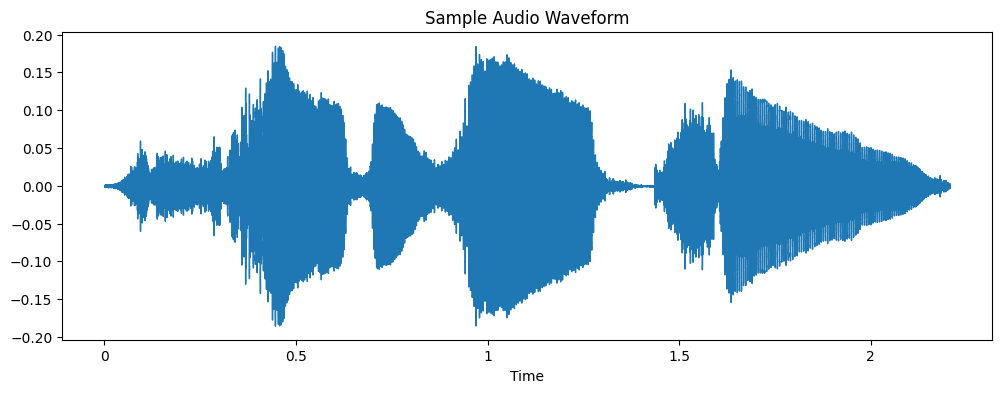

In [ ]:
# YOUR CODE HERE
y, sr = librosa.load(tess_files[0])

plt.figure(figsize=(12,4))
librosa.display.waveshow(y, sr=sr)
plt.title("Sample Audio Waveform")
plt.show()


In [ ]:
def extract_features(file):
    y, sr = librosa.load(file, duration=3, offset=0.5)
    mfcc = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40).T, axis=0)
    chroma = np.mean(librosa.feature.chroma_stft(y=y, sr=sr).T, axis=0)
    mel = np.mean(librosa.feature.melspectrogram(y=y, sr=sr).T, axis=0)
    return np.hstack((mfcc, chroma, mel))


#### Create a dictionary or a function to encode the emotions

In [ ]:
# YOUR CODE HERE
def get_ravdess_emotion(file):
    emotion_code = int(file.split("-")[2])
    emotion_map = {
        1:'neutral', 2:'calm', 3:'happy', 4:'sad',
        5:'angry', 6:'fearful', 7:'disgust', 8:'surprised'
    }
    return emotion_map[emotion_code]




#### TESS data feature extraction

In [ ]:
# YOUR CODE HERE
tess_features = []
tess_labels = []

for file in tess_files:
    tess_features.append(extract_features(file))
    tess_labels.append(file.split("/")[-2].lower())


#### Ravdess data feature extraction

In [ ]:
ravdess_features = []
ravdess_labels = []

for file in ravdess_files:
    ravdess_features.append(extract_features(file))
    ravdess_labels.append(get_ravdess_emotion(file))


#### Save the features

It is best advised to save the features in dataframe and maintain so that feature extraction step is not required to be performed every time.

* Make a DataFrame with features and labels

* Write dataframe into `.CSV` file and save it offline.

In [ ]:
# Combine TESS and RAVDESS features and labels
import numpy as np
import pandas as pd

# Stack features vertically and labels horizontally
X = np.vstack((tess_features, ravdess_features))
y = np.hstack((tess_labels, ravdess_labels))

# Create a DataFrame to store the combined data
df_combined = pd.DataFrame(X)
df_combined['emotion'] = y

# Display the shape and a few rows
print(f"Combined Feature Shape: {X.shape}")
print(f"Combined Labels Shape: {y.shape}")
display(df_combined.head())

# Save for future use
df_combined.to_csv("combined_speech_features.csv", index=False)
print("Features saved to combined_speech_features.csv")

Combined Feature Shape: (3847, 180)
Combined Labels Shape: (3847,)


,0,1,2,3,4,5,6,7,8,9,...,171,172,173,174,175,176,177,178,179,emotion
0,-402.580750,76.041267,30.245148,44.970127,-1.916473,3.777941,2.975150,-13.989454,-1.435665,-5.913465,...,0.001690,0.001534,0.001522,0.000775,0.000656,0.000348,0.000293,0.000181,0.000011,yaf_sad
1,-426.213013,90.701378,15.572073,24.682665,-5.041165,11.372180,3.633289,-16.863230,0.506846,-3.148163,...,0.000137,0.000178,0.000112,0.000091,0.000104,0.000091,0.000091,0.000044,0.000003,yaf_sad
2,-419.636292,91.189278,22.526852,31.775757,0.457400,12.248010,-3.367408,-14.419562,6.282846,-3.938117,...,0.001043,0.000551,0.000646,0.000502,0.000441,0.000307,0.000247,0.000200,0.000011,yaf_sad
3,-441.025726,101.101219,30.865120,40.541813,12.612633,12.765515,1.822928,-9.592519,2.034919,-7.344584,...,0.000065,0.000059,0.000071,0.000063,0.000064,0.000055,0.000065,0.000035,0.000002,yaf_sad
4,-428.133209,101.983315,28.072350,39.256958,9.232816,12.288920,-0.322115,-20.615067,8.242432,-10.818135,...,0.000061,0.000059,0.000088,0.000107,0.000083,0.000063,0.000046,0.000029,0.000004,yaf_sad


Features saved to combined_speech_features.csv


#### Split the data into train and test

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# YOUR CODE HERE
le = LabelEncoder()
y_encoded = le.fit_transform(y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

### Train the model with TESS + Ravdess data

* Apply DecisionTree and find clasification report, confusion matrix, AUC-ROC curve

Classification Report:
               precision    recall  f1-score   support

        angry       0.54      0.53      0.54        36
      disgust       0.32      0.33      0.32        36
      fearful       0.26      0.22      0.24        36
        happy       0.20      0.23      0.21        35
      neutral       0.47      0.44      0.46        18
    oaf_angry       1.00      0.89      0.94        38
  oaf_disgust       0.80      0.82      0.81        39
     oaf_fear       0.95      1.00      0.97        38
    oaf_happy       0.91      0.86      0.89        37
  oaf_neutral       1.00      0.97      0.99        38
      oaf_sad       0.90      0.97      0.94        37
oaf_surprised       0.90      0.90      0.90        39
          sad       0.42      0.41      0.41        37
    surprised       0.31      0.31      0.31        36
    yaf_angry       0.92      0.89      0.91        38
  yaf_disgust       0.89      0.87      0.88        39
     yaf_fear       0.97      0.87      0

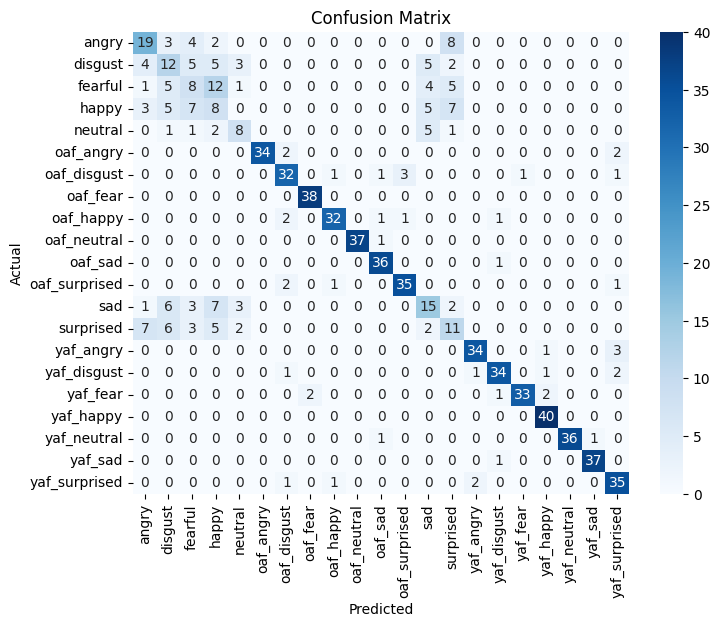

AUC ROC Score: 0.8590008576604033


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# YOUR CODE HERE
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

y_test_bin = label_binarize(y_test, classes=np.unique(y_encoded))
y_pred_prob = model.predict_proba(X_test)

auc = roc_auc_score(y_test_bin, y_pred_prob, multi_class="ovr")
print("AUC ROC Score:", auc)